In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
PTM_data = pd.read_csv("../r_WT_Mat_0001_0004_out_no_glycans/Full_run.sc", delim_whitespace=True,skiprows=[0])
PTM_data['position'] = PTM_data['description'].str.rsplit('_', n=2).str[1]
PTM_data['position'] = PTM_data['position'].astype(int)


In [45]:
import glob
import os

# Split 'description' before the second last occurrence of "_"
descriptions_split = PTM_data['description'].str.rsplit('_', n=2).str[0]
unique_names = descriptions_split.unique()

print(f"Unique prefixes before second last '_': {list(unique_names)}")
print(f"Number of unique names: {len(unique_names)}")

pdb_dir = "../input_files"
pdb_files_per_name = {}
glycan_positions_per_pdb = {}

# You'll need to define or import get_n_glyco_sites and determine the chain_id
chain_id = 'A'  # adjust as needed

for name in unique_names:
    # Search for PDB files for each unique name
    pattern = os.path.join(pdb_dir, f"{name}*.pdb")
    matching_files = glob.glob(pattern)
    pdb_files_per_name[name] = matching_files
    print(f"For name '{name}', found {len(matching_files)} PDB files: {matching_files}")
    for pdb_file in matching_files:
        try:
            n_glyco_sites, seq = get_n_glyco_sites(pdb_file, chain_id)
            glycan_positions_per_pdb[pdb_file] = n_glyco_sites
            print(f"Glycan positions in '{pdb_file}': {n_glyco_sites}")
        except Exception as e:
            print(f"Error parsing glycan positions for '{pdb_file}': {e}")

# Add the unique names (prefixes) as a column for grouping
PTM_data['name_prefix'] = descriptions_split
# Group the dataframe by the unique names
grouped_by_name = PTM_data.groupby('name_prefix')
print("Grouped dataframe by 'name_prefix'. Group sizes:")
print(grouped_by_name.size())


Unique prefixes before second last '_': ['r_WT_Mat_0001_0004']
Number of unique names: 1
For name 'r_WT_Mat_0001_0004', found 1 PDB files: ['../input_files/r_WT_Mat_0001_0004.pdb']
QLINTNGSWHINRTALNCNDSLQTGFITSLFYAKNVDSSGCPERMAACGSSGCWHYAPRPCDVVSARTVCGPVYCFTPSPVVVGTTDKLGIPTYNWGENETDVFMLESLRPPTGGWFGCTWMNSTGFTKTCGAPPGGPTDGGSGPWITPRCLVDYPYRLWHYPCTVNFTLHKVRMFVGGIEHRFDAACN
Glycan positions in '../input_files/r_WT_Mat_0001_0004.pdb': [6, 12, 19, 99, 123, 167]
Grouped dataframe by 'name_prefix'. Group sizes:
name_prefix
r_WT_Mat_0001_0004    90
dtype: int64


In [32]:
grouped_by_name.head()

,SCORE:,total_score,PTMPredictionMetric_9,RMSD_filter,dslf_fa13,fa_atr,fa_dun_dev,fa_dun_rot,fa_dun_semi,fa_elec,...,r_sasa,r_total_energy,rama_prepro,ref,total_score_filter,final_sequence,native_sequence,description,position,name_prefix
0,SCORE:,-952.104,0.614,0.580,-9.052,-2317.998,49.683,167.914,298.749,-839.126,...,128.821,-952.104,116.053,-64.773,-952.104,GSNNS,GSWHI,r_WT_Mat_0001_0004_9_0001,9,r_WT_Mat_0001_0004
1,SCORE:,-947.889,0.615,0.670,-9.057,-2323.811,49.991,169.216,296.162,-842.294,...,146.058,-947.889,120.439,-64.192,-947.889,TNNST,TNGSW,r_WT_Mat_0001_0004_7_0001,7,r_WT_Mat_0001_0004
2,SCORE:,-951.007,0.835,0.739,-9.024,-2322.544,49.924,169.173,297.184,-842.063,...,40.777,-951.007,118.246,-63.974,-951.007,NGNDS,NGSWH,r_WT_Mat_0001_0004_8_0001,8,r_WT_Mat_0001_0004
3,SCORE:,-952.047,0.610,0.549,-9.052,-2318.079,49.783,167.897,298.040,-839.512,...,130.573,-952.047,116.253,-64.773,-952.047,GSNNS,GSWHI,r_WT_Mat_0001_0004_9_0002,9,r_WT_Mat_0001_0004
4,SCORE:,-951.478,0.550,0.500,-9.071,-2320.403,50.110,169.965,295.839,-844.397,...,33.025,-951.478,117.567,-61.272,-951.478,SWNRS,SWHIN,r_WT_Mat_0001_0004_10_0001,10,r_WT_Mat_0001_0004


In [44]:
from Bio import SeqIO
import re
import warnings

# Suppress Biopython PDBConstructionWarning (from Bio.PDB.PDBExceptions)
try:
    from Bio import BiopythonWarning
    from Bio.PDB.PDBExceptions import PDBConstructionWarning, BiopythonWarning
    warnings.simplefilter("ignore", PDBConstructionWarning)
    warnings.simplefilter("ignore", BiopythonWarning)
except ImportError:
    pass  # fail silently if not Biopython 1.78+ or doesn't have PDBConstructionWarning

def get_n_glyco_sites(pdb_file, chain_id):
    """
    Extracts the sequence of the specified chain from the given PDB file using Bio.SeqIO,
    finds all N{P}[S/T] motifs (where {} is not P), and returns 1-indexed positions of N.

    Args:
        pdb_file (str): Path to the pdb file.
        chain_id (str): Chain identifier.
    Returns:
        n_positions (list): 1-indexed positions of N's with N-glyco motif in chain.
        sequence (str): The extracted sequence for reference.
    """
    sequence = None
    res_indices = []

    # Bio.SeqIO with format "pdb-atom" extracts each chain/SEQRES as a record
    for record in SeqIO.parse(pdb_file, "pdb-atom"):
        if record.id.split(":")[-1] == chain_id:
            sequence = str(record.seq)
            # Generate corresponding residue indices (1-based), assuming the sequence maps directly to PDB res numbers sequentially.
            res_indices = list(range(1, len(sequence)+1))
            print(sequence)
            break

    if sequence is None:
        raise ValueError(f"Chain '{chain_id}' not found in {pdb_file}.")

    # Find N-glycosylation motifs N{P}[S/T]
    matches = [
        m.start() for m in re.finditer(r'N[^P][ST]', sequence)
    ]
    # Map motif sequence indices to (1-based) positions
    n_positions = [res_indices[m] for m in matches]

    return n_positions, sequence

# Example usage:
# for record in SeqIO.parse(target, "pdb-atom"):
#     print(record.seq)


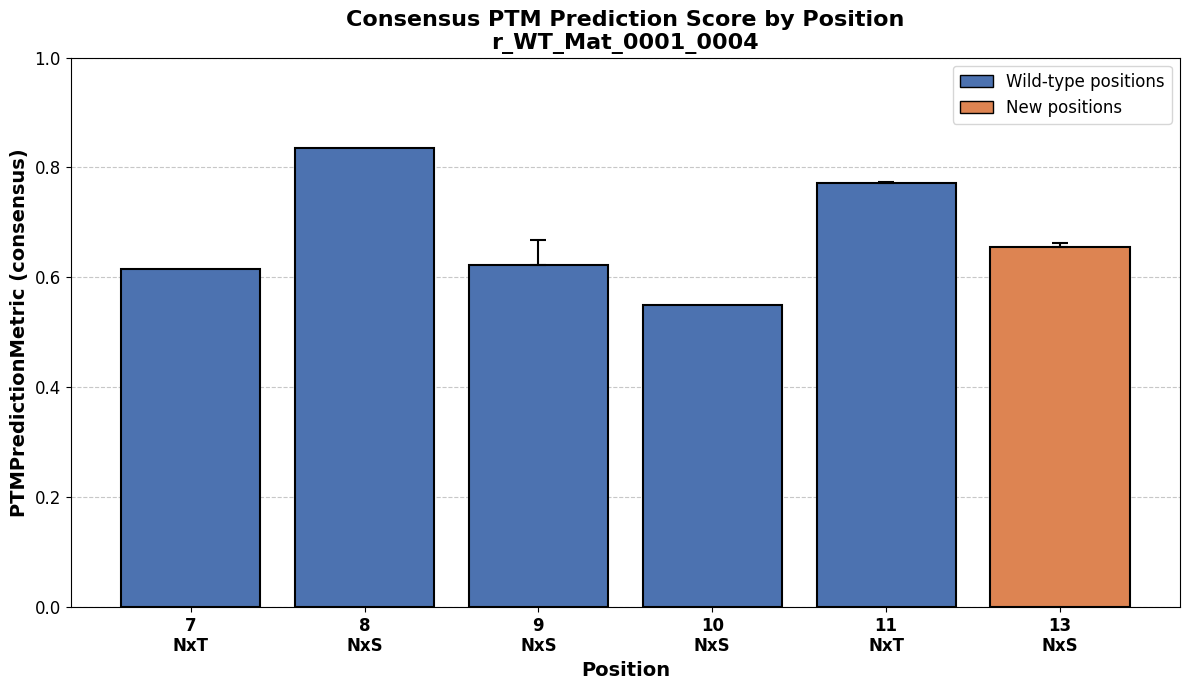

In [49]:
from matplotlib.patches import Patch
import numpy as np

def get_sequon_from_final_sequence(seq):
    """
    Returns the sequon from the final_sequence using the third and last amino acid
    (N at position 3, S/T at last position) as NxT or NxS. If not a valid sequon, return None.
    """
    if not isinstance(seq, str) or len(seq) < 3:
        return None
    third = seq[2]
    last = seq[-1]
    if third.upper() == "N" and last.upper() in ["S", "T"]:
        return f"Nx{last.upper()}"
    return None

def plot_ptm_by_position(df, wild_type_positions, name_label):
    """
    Plots the consensus PTMPredictionMetric_9 by position for the given dataframe,
    and annotates each xtick with the sequon(s) and their frequencies for both new and wild-type positions.
    """
    all_positions = sorted(df['position'].unique())

    # Group by 'position' and get consensus (mean) and standard deviation
    ptm_mean = df.groupby('position')['PTMPredictionMetric_9'].mean().sort_index()
    ptm_std = df.groupby('position')['PTMPredictionMetric_9'].std().sort_index()

    # --- Build position: sequon freq mapping for all positions ---
    position_labels = []
    for pos in ptm_mean.index:
        subdf = df[df['position'] == pos]
        sequons = subdf['final_sequence'].apply(get_sequon_from_final_sequence).dropna()
        if len(sequons) > 0:
            value_counts = sequons.value_counts(normalize=True)
            label = f"{pos}\n"
            if len(value_counts) == 1:
                seq_label = value_counts.index[0]
                label += f"{seq_label}"
            else:
                label += " ".join(
                    f"{seq} ({int(round(freq*100))}%)"
                    for seq, freq in value_counts.items()
                )
        else:
            label = str(pos)
        position_labels.append(label)

    # Prepare color map
    bar_colors = ['#4C72B0' if pos in wild_type_positions else '#DD8452' for pos in ptm_mean.index]

    plt.figure(figsize=(12, 7))
    bars = plt.bar(
        np.arange(len(ptm_mean)),
        ptm_mean.values,
        color=bar_colors,
        edgecolor='black',
        linewidth=1.5,
    )

    for i, (x, mean, std) in enumerate(zip(np.arange(len(ptm_mean)), ptm_mean.values, ptm_std.values)):
        error_top = max(0, std)
        if error_top > 0:
            plt.errorbar(
                x=x,
                y=mean,
                yerr=[[0], [error_top]],
                fmt='none',
                ecolor='black',
                elinewidth=1.5,
                capsize=6,
                capthick=1.5,
            )

    plt.ylim(0, 1)
    plt.xlabel("Position", fontsize=14, fontweight='bold')
    plt.ylabel("PTMPredictionMetric (consensus)", fontsize=14, fontweight='bold')
    plt.title(f"Consensus PTM Prediction Score by Position\n{name_label}", fontsize=16, fontweight='bold')

    plt.xticks(ticks=np.arange(len(ptm_mean)), labels=position_labels, fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_axisbelow(True)

    legend_elements = [
        Patch(facecolor='#4C72B0', edgecolor='black', label='Wild-type positions'),
        Patch(facecolor='#DD8452', edgecolor='black', label='New positions')
    ]
    plt.legend(handles=legend_elements, fontsize=12, frameon=True)

    plt.tight_layout()
    plt.show()

# Define wild-type positions (update as needed for your data)
wild_type_positions = [7, 8, 9, 10, 11]

# Generate the plot for each unique group in grouped_by_name
for name_label, group_df in grouped_by_name:
    plot_ptm_by_position(group_df, wild_type_positions, name_label)

In [27]:
PTM_data

,SCORE:,total_score,PTMPredictionMetric_9,RMSD_filter,dslf_fa13,fa_atr,fa_dun_dev,fa_dun_rot,fa_dun_semi,fa_elec,...,r_sasa,r_total_energy,rama_prepro,ref,total_score_filter,final_sequence,native_sequence,description,position,name_prefix
0,SCORE:,-952.104,0.614,0.580,-9.052,-2317.998,49.683,167.914,298.749,-839.126,...,128.821,-952.104,116.053,-64.773,-952.104,GSNNS,GSWHI,r_WT_Mat_0001_0004_9_0001,9,r_WT_Mat_0001_0004
1,SCORE:,-947.889,0.615,0.670,-9.057,-2323.811,49.991,169.216,296.162,-842.294,...,146.058,-947.889,120.439,-64.192,-947.889,TNNST,TNGSW,r_WT_Mat_0001_0004_7_0001,7,r_WT_Mat_0001_0004
2,SCORE:,-951.007,0.835,0.739,-9.024,-2322.544,49.924,169.173,297.184,-842.063,...,40.777,-951.007,118.246,-63.974,-951.007,NGNDS,NGSWH,r_WT_Mat_0001_0004_8_0001,8,r_WT_Mat_0001_0004
3,SCORE:,-952.047,0.610,0.549,-9.052,-2318.079,49.783,167.897,298.040,-839.512,...,130.573,-952.047,116.253,-64.773,-952.047,GSNNS,GSWHI,r_WT_Mat_0001_0004_9_0002,9,r_WT_Mat_0001_0004
4,SCORE:,-951.478,0.550,0.500,-9.071,-2320.403,50.110,169.965,295.839,-844.397,...,33.025,-951.478,117.567,-61.272,-951.478,SWNRS,SWHIN,r_WT_Mat_0001_0004_10_0001,10,r_WT_Mat_0001_0004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,SCORE:,-946.007,0.652,0.675,-8.925,-2321.983,50.644,167.515,300.698,-840.351,...,8.980,-946.007,117.499,-57.246,-946.007,INNVS,INRTA,r_WT_Mat_0001_0004_13_0014,13,r_WT_Mat_0001_0004
86,SCORE:,-947.546,0.772,1.026,-9.010,-2313.538,49.242,165.876,299.698,-843.521,...,46.149,-947.546,118.785,-61.359,-947.546,WHNET,WHINR,r_WT_Mat_0001_0004_11_0013,11,r_WT_Mat_0001_0004
87,SCORE:,-946.026,0.652,0.683,-8.911,-2322.052,50.644,167.508,300.666,-840.324,...,8.980,-946.026,117.515,-57.246,-946.026,INNVS,INRTA,r_WT_Mat_0001_0004_13_0015,13,r_WT_Mat_0001_0004
88,SCORE:,-947.581,0.775,0.786,-9.007,-2313.722,49.326,165.872,299.667,-843.525,...,47.300,-947.581,118.797,-61.359,-947.581,WHNET,WHINR,r_WT_Mat_0001_0004_11_0014,11,r_WT_Mat_0001_0004
